# Entregable 2 - Seminario de Ciencia de Datos
## Reducción de Dimensionalidad y Modelamiento Supervisado

**Dataset:** Heart Disease - Cleveland (UCI Machine Learning Repository)
**Autor:** Jaime Alzate
**Programa:** Desarrollo de Software - 9° semestre

---

### Lo que voy a hacer en este entregable

- **Tópico VI:** Aplicar PCA y decidir cuantos componentes uso
- **Tópico VII:** Seleccionar las 5 mejores variables con un filtro
- **Tópico VIII:** Entrenar y comparar 2 modelos supervisados
- **Tópico IX:** Conclusiones (en el documento Word)

### Nota importante

Este notebook se puede ejecutar de forma independiente del Entregable 1.
Aquí mismo reconstruyo el preprocesamiento que hice antes (capping +
imputacion bayesiana) para que el profesor pueda correrlo desde cero.

## 🔗 Recursos del Proyecto

- **Repositorio (GitHub):** https://github.com/JAAM010/seminario-datos-heart-disease
- **Dashboard interactivo (en vivo):** https://heart-disease-jaam010.streamlit.app

> El dashboard, hecho en Streamlit como valor agregado, permite explorar el análisis (EDA, PCA, comparación de modelos) y **predecir el diagnóstico de un paciente nuevo en línea**, sin instalar nada.

---

In [1]:
# Importo todo lo necesario
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Para preprocesamiento
from sklearn.experimental import enable_iterative_imputer  # debe ir antes
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge
from sklearn.preprocessing import StandardScaler

# Para PCA
from sklearn.decomposition import PCA

# Para los modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Para la division y validacion
from sklearn.model_selection import train_test_split, cross_val_score

# Metricas
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve)

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Semilla para reproducibilidad
SEED = 42

## Reconstrucción del preprocesamiento del Entregable 1

Vuelvo a aplicar lo mismo: cargar el dataset, crear el target binario,
capping con IQR y imputacion bayesiana.

In [2]:
# Cargo el dataset desde UCI
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
columnas = ['age','sex','cp','trestbps','chol','fbs','restecg',
            'thalach','exang','oldpeak','slope','ca','thal','num']

df = pd.read_csv(url, header=None, names=columnas, na_values='?')

# Creo el target binario y elimino num original
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

print('Dataset cargado:', df.shape)
df.head()

Dataset cargado: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Capping de outliers con IQR (igual que en el Entregable 1)
variables_numericas = ['age','trestbps','chol','thalach','oldpeak','ca']

for col in variables_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lim_inf, upper=lim_sup)

print('Capping aplicado')

Capping aplicado


In [4]:
# Imputacion bayesiana iterativa para los nulos numericos
imputador = IterativeImputer(estimator=BayesianRidge(), max_iter=20, random_state=SEED)
df[variables_numericas] = imputador.fit_transform(df[variables_numericas])

# Para thal (categorica) uso la moda
df['thal'] = df['thal'].fillna(df['thal'].mode()[0])

# Verifico que no queden nulos
print('Nulos restantes:', df.isnull().sum().sum())

Nulos restantes: 0


In [5]:
# Separo features (X) y target (y)
features = [c for c in df.columns if c != 'target']
X = df[features].copy()
y = df['target'].copy()

print('Features:', features)
print('X shape:', X.shape)
print('Target balance:', y.value_counts().to_dict())

Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
X shape: (303, 13)
Target balance: {0: 164, 1: 139}


## VI. Análisis de Componentes Principales (PCA)

PCA es sensible a la escala de las variables, asi que primero las estandarizo
(media 0, desviacion 1). Despues aplico PCA y reviso cuanta varianza explica
cada componente.

In [6]:
# Estandarizo las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Aplico PCA sin limitar componentes (para ver todo el espectro)
pca = PCA()
pca.fit(X_scaled)

# Varianza explicada por cada componente
varianza_individual = pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_individual)

# Tabla para verlo claro
tabla_pca = pd.DataFrame({
    'componente': ['PC' + str(i+1) for i in range(len(varianza_individual))],
    'varianza_individual': varianza_individual.round(4),
    'varianza_acumulada': varianza_acumulada.round(4)
})
tabla_pca

,componente,varianza_individual,varianza_acumulada
0,PC1,0.2376,0.2376
1,PC2,0.1228,0.3604
2,PC3,0.0952,0.4557
3,PC4,0.0846,0.5403
4,PC5,0.0758,0.6160
5,PC6,0.0673,0.6833
6,PC7,0.0665,0.7499
7,PC8,0.0597,0.8096
8,PC9,0.0517,0.8613
9,PC10,0.0434,0.9047


In [7]:
# ¿Cuantos componentes necesito para distintos umbrales de varianza?
n_para_80 = np.argmax(varianza_acumulada >= 0.80) + 1
n_para_90 = np.argmax(varianza_acumulada >= 0.90) + 1
n_para_95 = np.argmax(varianza_acumulada >= 0.95) + 1

print('Componentes para 80% de varianza:', n_para_80)
print('Componentes para 90% de varianza:', n_para_90)
print('Componentes para 95% de varianza:', n_para_95)

Componentes para 80% de varianza: 8
Componentes para 90% de varianza: 10
Componentes para 95% de varianza: 12


Con 8 componentes ya tengo el 80% de la varianza. Es un buen punto de
corte porque paso de 13 variables a 8 (reduccion del 38%) sin perder mucha
informacion.

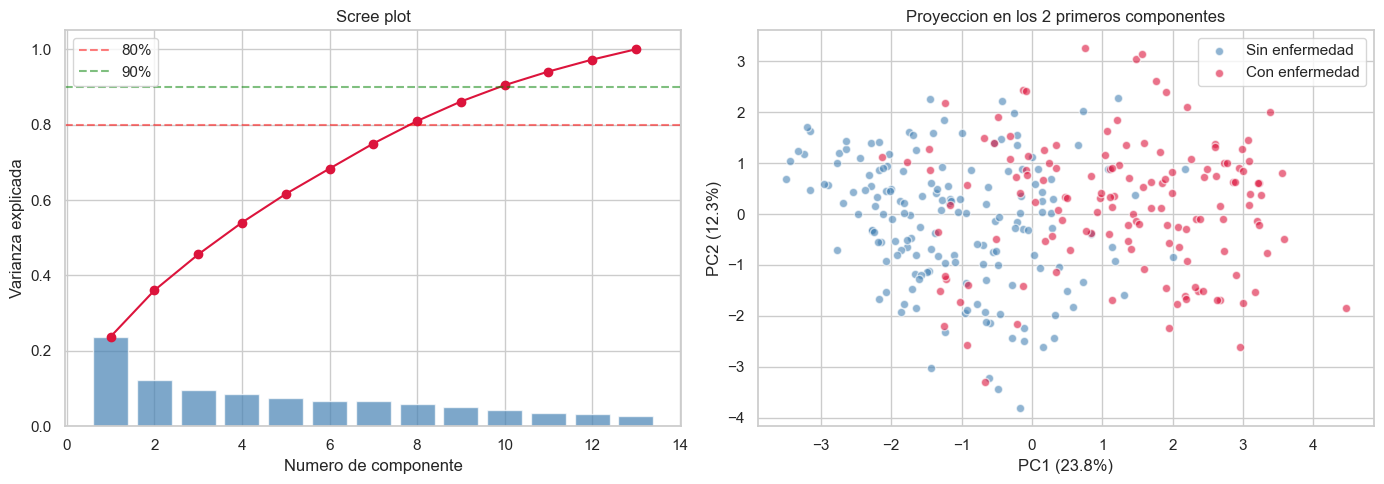

In [8]:
# Grafico del scree plot + proyeccion 2D
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# === Izquierda: scree plot ===
componentes = range(1, len(varianza_individual) + 1)
axes[0].bar(componentes, varianza_individual, alpha=0.7, color='steelblue')
axes[0].plot(componentes, varianza_acumulada, marker='o', color='crimson')
axes[0].axhline(0.80, color='red', linestyle='--', alpha=0.5, label='80%')
axes[0].axhline(0.90, color='green', linestyle='--', alpha=0.5, label='90%')
axes[0].set_xlabel('Numero de componente')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Scree plot')
axes[0].legend()

# === Derecha: proyeccion 2D ===
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_scaled)

# Coloreo por target
for clase, color, etiqueta in [(0, 'steelblue', 'Sin enfermedad'),
                                (1, 'crimson', 'Con enfermedad')]:
    mascara = (y == clase)
    axes[1].scatter(X_2d[mascara, 0], X_2d[mascara, 1],
                    c=color, label=etiqueta, alpha=0.6, edgecolor='white')

pct_pc1 = pca_2d.explained_variance_ratio_[0] * 100
pct_pc2 = pca_2d.explained_variance_ratio_[1] * 100
axes[1].set_xlabel('PC1 (' + str(round(pct_pc1, 1)) + '%)')
axes[1].set_ylabel('PC2 (' + str(round(pct_pc2, 1)) + '%)')
axes[1].set_title('Proyeccion en los 2 primeros componentes')
axes[1].legend()

plt.tight_layout()
plt.show()

**Justificación del número de componentes:** elijo **8 componentes** porque:
1. Acumulan el 80% de la varianza (umbral comun)
2. Reducen el dataset un 38% (de 13 a 8)
3. En el scree plot se ve que despues del 8vo componente la curva se aplana

En la proyeccion 2D ya se ven dos grupos parcialmente separados, lo cual es
buena señal para el modelado.

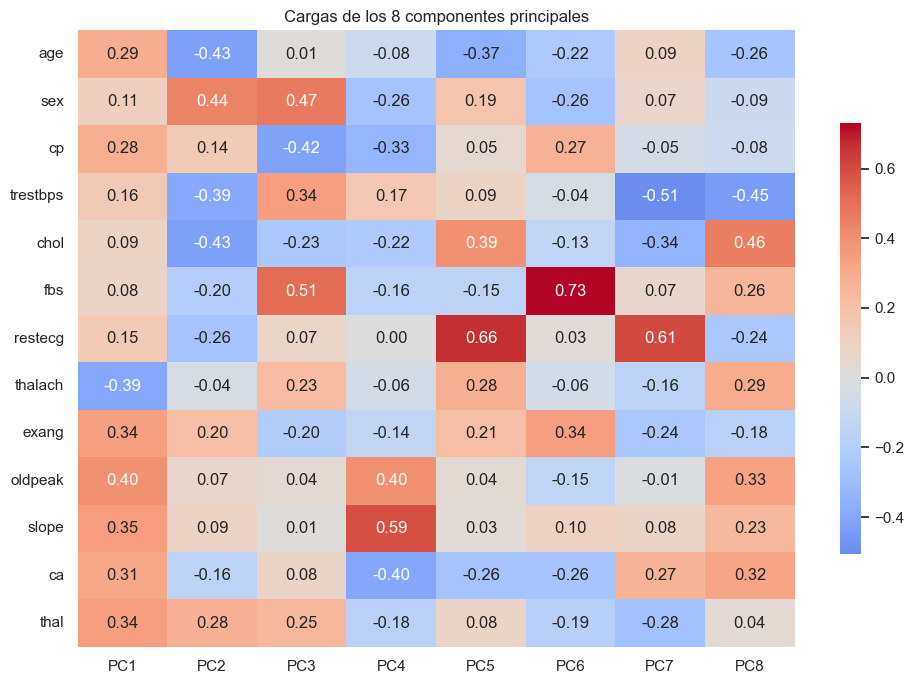

In [9]:
# Mapa de cargas (loadings) de los primeros 8 componentes
# Sirve para interpretar que significa cada componente

loadings = pd.DataFrame(
    pca.components_[:8].T,  # Tomo solo los primeros 8 componentes
    columns=['PC' + str(i+1) for i in range(8)],
    index=features
)

plt.figure(figsize=(10, 7))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            cbar_kws={'shrink': 0.7})
plt.title('Cargas de los 8 componentes principales')
plt.tight_layout()
plt.show()

**Interpretación:**
- **PC1** carga sobre `oldpeak`, `exang`, `thal` y `ca` (todas variables de
  sintomas / hallazgos clinicos) → lo interpreto como un **eje de severidad cardíaca**
- **PC2** carga sobre `sex`, `chol`, `age` → un **eje demográfico-metabólico**

## VII. Selección de Características (Filtro por correlación)

Uso la correlacion absoluta de Pearson entre cada variable y el target.
Las 5 con mayor correlacion son las "mas predictivas" segun este criterio.

In [10]:
# Calculo correlacion absoluta de cada variable con el target
correlacion_target = X.corrwith(y).abs().sort_values(ascending=False)
correlacion_target.round(4)

thal        0.5221
ca          0.4702
exang       0.4319
oldpeak     0.4303
thalach     0.4176
cp          0.4144
slope       0.3392
sex         0.2768
age         0.2231
restecg     0.1692
trestbps    0.1450
chol        0.1039
fbs         0.0253
dtype: float64

In [11]:
# Me quedo con las 5 mas correlacionadas
top_5 = correlacion_target.head(5)

print('Top 5 variables mas correlacionadas con el target:')
print(top_5.round(4))

Top 5 variables mas correlacionadas con el target:
thal       0.5221
ca         0.4702
exang      0.4319
oldpeak    0.4303
thalach    0.4176
dtype: float64


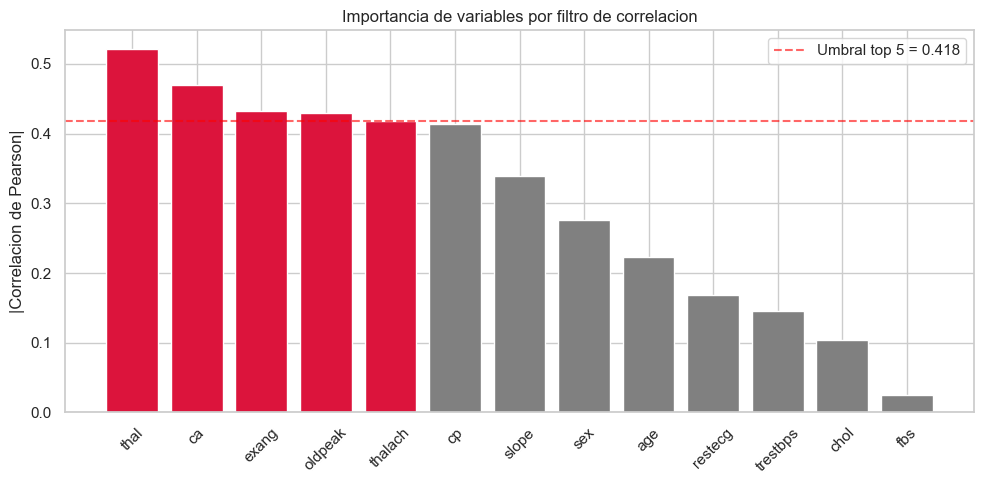

In [12]:
# Grafico de barras destacando el top 5
plt.figure(figsize=(10, 5))

# Colores: las del top 5 en rojo, las otras en gris
colores = []
umbral = top_5.min()
for valor in correlacion_target:
    if valor >= umbral:
        colores.append('crimson')
    else:
        colores.append('gray')

plt.bar(correlacion_target.index, correlacion_target.values,
        color=colores, edgecolor='white')
plt.axhline(umbral, color='red', linestyle='--', alpha=0.6,
            label='Umbral top 5 = ' + str(round(umbral, 3)))
plt.xticks(rotation=45)
plt.ylabel('|Correlacion de Pearson|')
plt.title('Importancia de variables por filtro de correlacion')
plt.legend()
plt.tight_layout()
plt.show()

Las 5 mejores son: `thal`, `ca`, `exang`, `oldpeak` y `thalach`. Tiene sentido
clinico: casi todas son sintomas o respuesta al ejercicio.

Las menos correlacionadas (`fbs`, `chol`, `trestbps`) son factores de riesgo a
largo plazo pero no predicen tan bien el estado actual.

## VIII. Modelamiento Supervisado

Comparo 2 modelos vistos en clase:
1. **Regresión Logística** (parametrico, lineal)
2. **Árbol de Decisión** (no parametrico, no lineal)

División: 80% entrenamiento, 20% prueba, estratificado para mantener el
balance de clases.

In [13]:
# Divido en train y test (estratificado)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=SEED,
    stratify=y  # importante para mantener el balance de clases
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)
print('Balance train:', y_train.value_counts().to_dict())
print('Balance test:', y_test.value_counts().to_dict())

Train: (242, 13)
Test: (61, 13)
Balance train: {0: 131, 1: 111}
Balance test: {0: 33, 1: 28}


In [14]:
# Para la regresion logistica necesito estandarizar
# (el arbol no, porque se basa en divisiones, no en distancias)
scaler_modelo = StandardScaler()
X_train_scaled = scaler_modelo.fit_transform(X_train)
X_test_scaled = scaler_modelo.transform(X_test)

In [15]:
# === MODELO 1: Regresion Logistica ===
modelo_log = LogisticRegression(max_iter=2000, random_state=SEED)
modelo_log.fit(X_train_scaled, y_train)

# Predicciones
y_pred_log = modelo_log.predict(X_test_scaled)
y_prob_log = modelo_log.predict_proba(X_test_scaled)[:, 1]  # probabilidad de la clase 1

print('Regresion Logistica entrenada')

Regresion Logistica entrenada


In [16]:
# === MODELO 2: Arbol de Decision ===
# Limito la profundidad para evitar sobreajuste
# class_weight='balanced' porque hay desbalance leve

modelo_arbol = DecisionTreeClassifier(
    max_depth=5,
    random_state=SEED,
    class_weight='balanced'
)
modelo_arbol.fit(X_train, y_train)  # sin estandarizar

# Predicciones
y_pred_arbol = modelo_arbol.predict(X_test)
y_prob_arbol = modelo_arbol.predict_proba(X_test)[:, 1]

print('Arbol de Decision entrenado')

Arbol de Decision entrenado


In [17]:
# Comparo las metricas de los dos modelos
def calcular_metricas(nombre, y_real, y_pred, y_prob):
    return {
        'modelo': nombre,
        'accuracy': round(accuracy_score(y_real, y_pred), 4),
        'precision': round(precision_score(y_real, y_pred), 4),
        'recall': round(recall_score(y_real, y_pred), 4),
        'f1': round(f1_score(y_real, y_pred), 4),
        'roc_auc': round(roc_auc_score(y_real, y_prob), 4)
    }

resultados = pd.DataFrame([
    calcular_metricas('Regresion Logistica', y_test, y_pred_log, y_prob_log),
    calcular_metricas('Arbol de Decision', y_test, y_pred_arbol, y_prob_arbol)
])

resultados

,modelo,accuracy,precision,recall,f1,roc_auc
0,Regresion Logistica,0.8525,0.7879,0.9286,0.8525,0.9535
1,Arbol de Decision,0.8033,0.7500,0.8571,0.8000,0.8052


In [18]:
# Validacion cruzada de 5 pliegues sobre el train
cv_log = cross_val_score(modelo_log, X_train_scaled, y_train, cv=5, scoring='accuracy')
cv_arbol = cross_val_score(modelo_arbol, X_train, y_train, cv=5, scoring='accuracy')

print('Validacion cruzada (accuracy promedio +/- desv. estandar):')
print('  Logistica: {:.4f} +/- {:.4f}'.format(cv_log.mean(), cv_log.std()))
print('  Arbol:     {:.4f} +/- {:.4f}'.format(cv_arbol.mean(), cv_arbol.std()))

Validacion cruzada (accuracy promedio +/- desv. estandar):
  Logistica: 0.8263 +/- 0.0504
  Arbol:     0.7151 +/- 0.0620


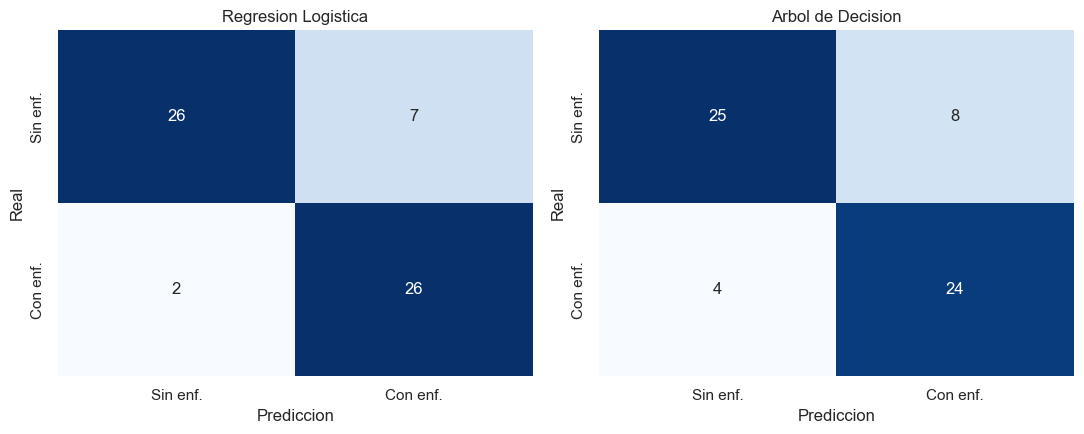

In [19]:
# Matrices de confusion de los dos modelos
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Logistica
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Sin enf.', 'Con enf.'],
            yticklabels=['Sin enf.', 'Con enf.'])
axes[0].set_title('Regresion Logistica')
axes[0].set_xlabel('Prediccion')
axes[0].set_ylabel('Real')

# Arbol
cm_arbol = confusion_matrix(y_test, y_pred_arbol)
sns.heatmap(cm_arbol, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1],
            xticklabels=['Sin enf.', 'Con enf.'],
            yticklabels=['Sin enf.', 'Con enf.'])
axes[1].set_title('Arbol de Decision')
axes[1].set_xlabel('Prediccion')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.show()

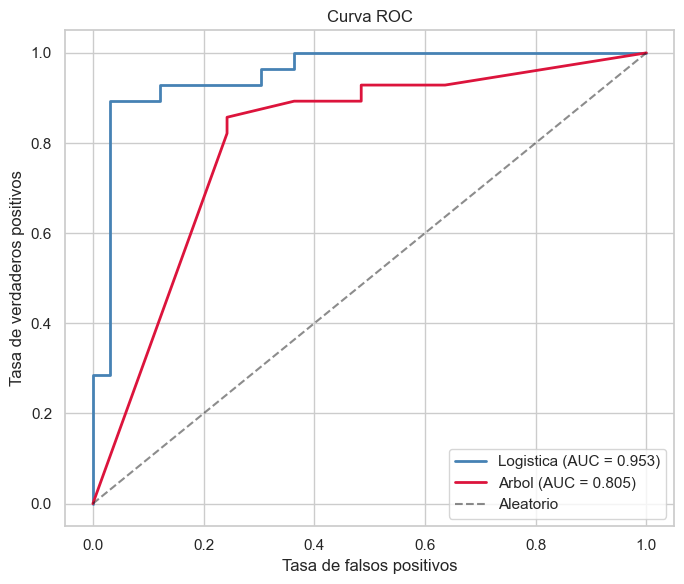

In [20]:
# Curva ROC
plt.figure(figsize=(7, 6))

# ROC de la logistica
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
auc_log = roc_auc_score(y_test, y_prob_log)
plt.plot(fpr_log, tpr_log, label='Logistica (AUC = {:.3f})'.format(auc_log),
         color='steelblue', linewidth=2)

# ROC del arbol
fpr_arbol, tpr_arbol, _ = roc_curve(y_test, y_prob_arbol)
auc_arbol = roc_auc_score(y_test, y_prob_arbol)
plt.plot(fpr_arbol, tpr_arbol, label='Arbol (AUC = {:.3f})'.format(auc_arbol),
         color='crimson', linewidth=2)

# Linea del clasificador aleatorio
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')

plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curva ROC')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Comentario:** la logistica gana en AUC (0.95 vs 0.81). La curva del arbol
tiene forma escalonada porque sus salidas son mas discretas, mientras que la
logistica produce probabilidades continuas.

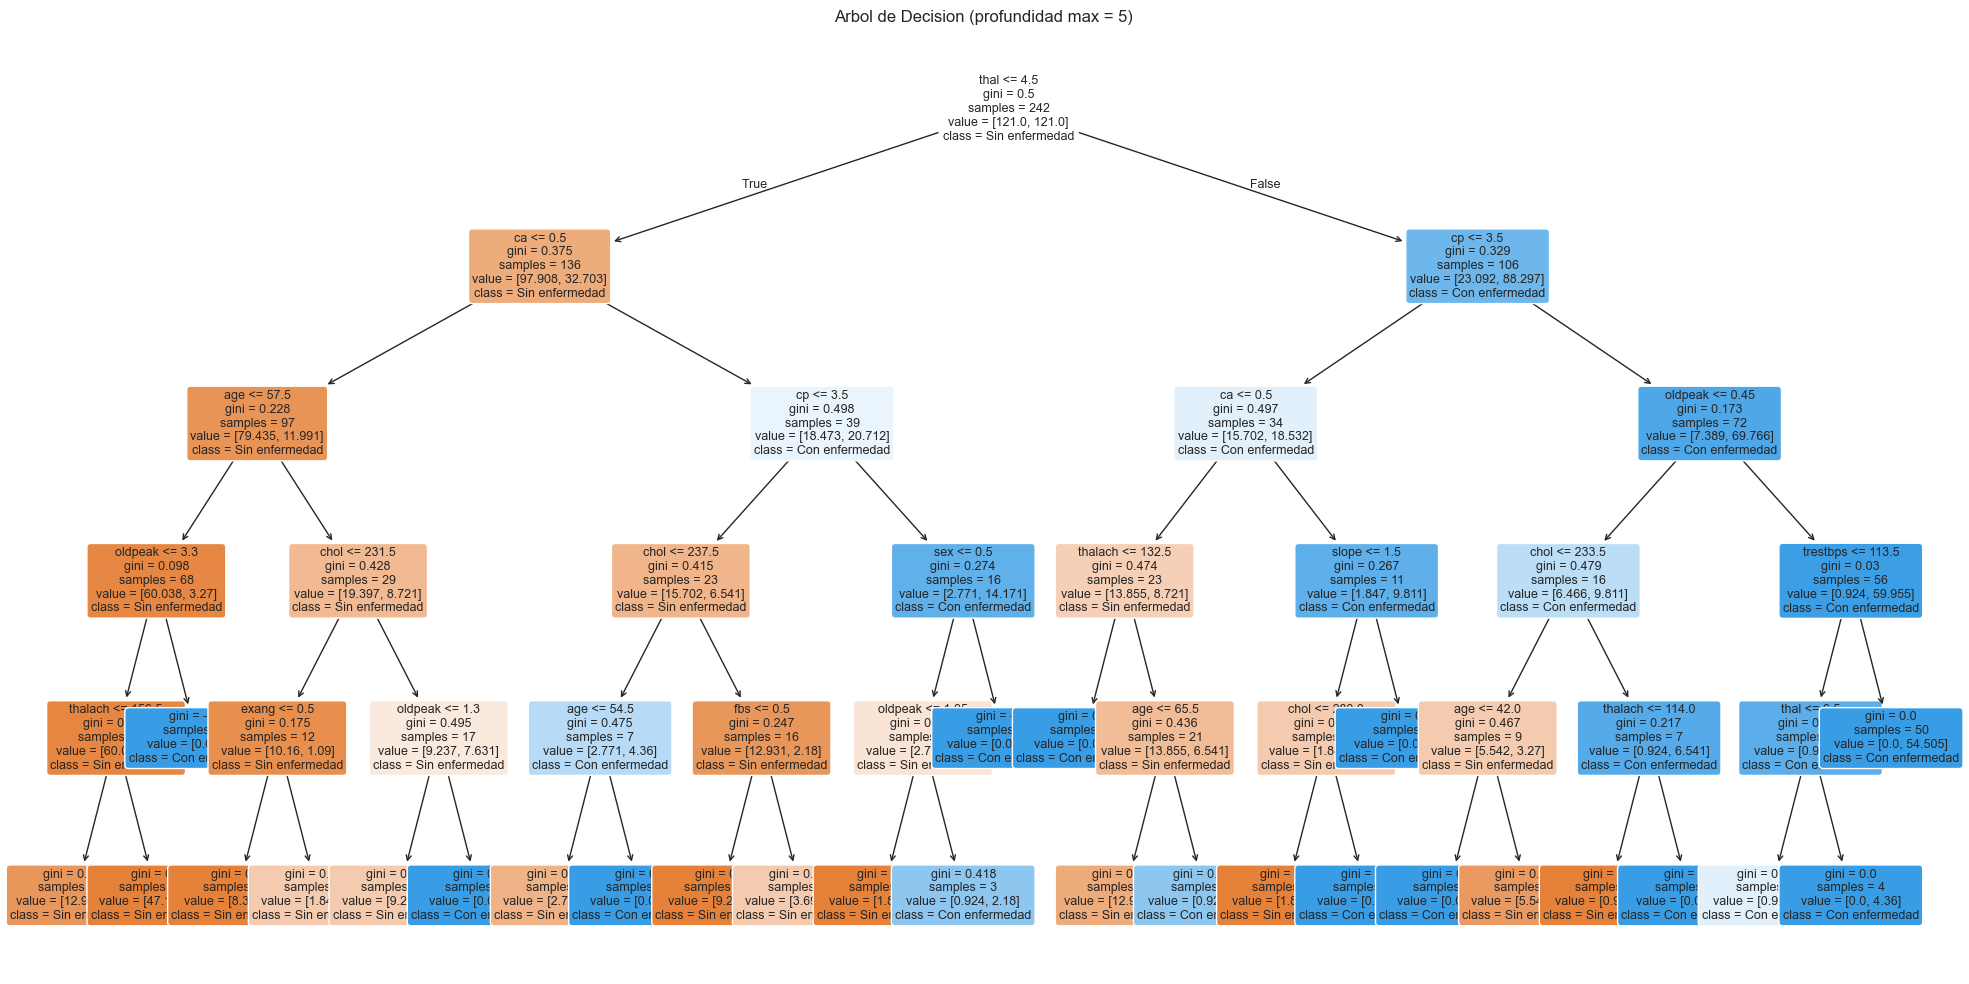

In [21]:
# Visualizo el arbol de decision
plt.figure(figsize=(20, 10))
plot_tree(modelo_arbol,
          feature_names=features,
          class_names=['Sin enfermedad', 'Con enfermedad'],
          filled=True, rounded=True, fontsize=9)
plt.title('Arbol de Decision (profundidad max = 5)')
plt.tight_layout()
plt.show()

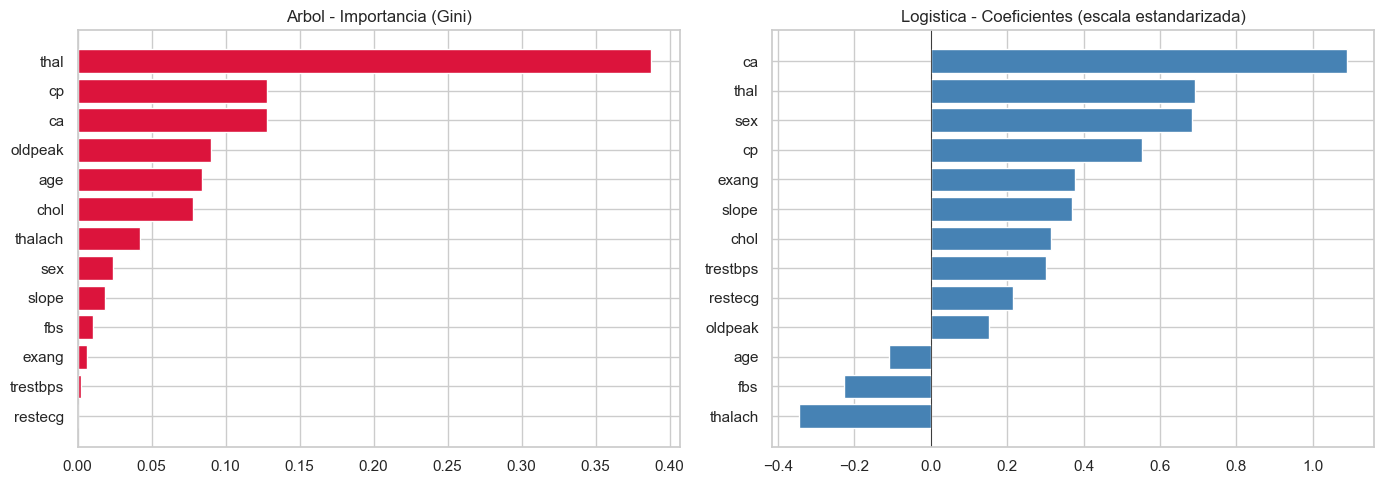

In [22]:
# Comparo importancia de variables: arbol vs logistica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Importancia del arbol (Gini)
imp_arbol = pd.Series(modelo_arbol.feature_importances_, index=features).sort_values()
axes[0].barh(imp_arbol.index, imp_arbol.values, color='crimson')
axes[0].set_title('Arbol - Importancia (Gini)')

# Coeficientes de la logistica
coef_log = pd.Series(modelo_log.coef_[0], index=features).sort_values()
axes[1].barh(coef_log.index, coef_log.values, color='steelblue')
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_title('Logistica - Coeficientes (escala estandarizada)')

plt.tight_layout()
plt.show()

In [23]:
# Reporte de clasificacion detallado
print('=== REGRESION LOGISTICA ===')
print(classification_report(y_test, y_pred_log,
                             target_names=['Sin enfermedad', 'Con enfermedad']))

print('=== ARBOL DE DECISION ===')
print(classification_report(y_test, y_pred_arbol,
                             target_names=['Sin enfermedad', 'Con enfermedad']))

=== REGRESION LOGISTICA ===
                precision    recall  f1-score   support

Sin enfermedad       0.93      0.79      0.85        33
Con enfermedad       0.79      0.93      0.85        28

      accuracy                           0.85        61
     macro avg       0.86      0.86      0.85        61
  weighted avg       0.86      0.85      0.85        61

=== ARBOL DE DECISION ===
                precision    recall  f1-score   support

Sin enfermedad       0.86      0.76      0.81        33
Con enfermedad       0.75      0.86      0.80        28

      accuracy                           0.80        61
     macro avg       0.81      0.81      0.80        61
  weighted avg       0.81      0.80      0.80        61



## Resumen de los resultados

| Metrica | Logistica | Arbol |
|---------|-----------|-------|
| Accuracy | 0.8525 | 0.8033 |
| Precision | 0.7879 | 0.7500 |
| Recall | 0.9286 | 0.8571 |
| F1 | 0.8525 | 0.8000 |
| ROC-AUC | 0.9535 | 0.8052 |

**Conclusiones rapidas:**
1. La **Regresion Logistica gana** en las 5 metricas
2. El recall del 92.9% es importante en un caso clinico (evitar falsos negativos)
3. La validacion cruzada confirma el patron y muestra que la logistica es mas estable
4. Las variables mas importantes coinciden con las que el filtro de correlacion habia identificado

El analisis completo, la reflexion y las conclusiones estan en el documento Word adjunto.